# 02-ドライバーのセグメンテーション

分類ルールを構築してセグメンテーションを行います。
分類ルールは
- サーキット走行回数
- サーキット走行時の最高車速
- 最高車速
- 走行距離

In [0]:
# カレントディレクトリを変更
import os
os.chdir('../')

# 必要なライブラリをインストール
!pip install snowflake-snowpark-python==1.39.0
!pip install -r requirements.txt

  Obtaining dependency information for snowflake-snowpark-python==1.39.0 from https://files.pythonhosted.org/packages/75/5c/88f3602c81fdc96608da7b5f48212069c1ae8b3e9bb3f67efebf9c0abd46/snowflake_snowpark_python-1.39.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/164.8 kB ? eta -:--:--
     ━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/164.8 kB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 2.6 MB/s eta 0:00:00
  Obtaining dependency information for snowflake-connector-python<4.0.0,>=3.17.0 from https://files.pythonhosted.org/packages/8a/bb/8213c682ea69cf50ba028db47469455cb7dba31b152b867ac3a468dcca19/snowflake_connector_python-3.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/74.8 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.7 MB/s eta 0:00:00
  Obtaining dependency information for tzlocal from https://files.pythonho

In [0]:
# python再起動
%restart_python

In [0]:
# 必要なモジュールをインポート
import os
import warnings
from dotenv import load_dotenv
os.chdir('../') # カレントディレクトリを変更
from src.plot_utils import *
from src.segmentation import *
from src.utils import *
warnings.simplefilter("ignore")
load_dotenv(".env")

# Snowflakeセッションを生成
snowflake_params = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT"),
    "user": os.getenv("SNOWFLAKE_USER"),
    "database": os.getenv("SNOWFLAKE_DB"),
}
session = get_snowflake_session(snowflake_params)

In [0]:
# VAPのテーブル名を辞書化
vap_table_name_dict = {
    "202410": os.getenv("SNOWFLAKE_TABLE_952W_202410"),
    "202504": os.getenv("SNOWFLAKE_TABLE_952W_202504"),
    "202510": os.getenv("SNOWFLAKE_TABLE_952W_202510"),
}

## 分析対象のVINを取得

In [0]:
# 分析対象のVINが保存されているディレクトリとファイル名
SAVE_DIR = 'notebook/data/01_select_target_vin'
FILE_NAME = '952w_target_vin_list_dict.pkl'

# VINの絞り込みに必要なデータを抽出
target_vin_list_dict = load_pkl(SAVE_DIR, FILE_NAME)

## セグメンテーションを行うための特徴量を作成

In [0]:
# Snowflakeからデータ抽出を行っていない場合はこちらを実行
# 【注意】処理に時間がかかります

# 抽出結果を保存するディレクトリとファイル名
SAVE_DIR = 'notebook/data/02_driver_segmentation'
FILE_NAME = '952w_tables_for_segmentation_dict.pkl'

# セグメンテーションに必要な特徴量データを作成
tables_for_segmentation_dict = {}
for key, table_name in vap_table_name_dict.items():
    print(f'[{key}]')
    tables_for_segmentation_dict[key] = get_feature_tables_for_segmentation(
        unique_vin_list=target_vin_list_dict[key],
        snowflake_session=session,
        data_params={
            "readonly_schema_name": os.getenv("SNOWFLAKE_SCHEMA_READONLY"),
            "schema_name": os.getenv("SNOWFLAKE_SCHEMA"),
            "can_table_name": table_name,
            "circuit_poi_table_name": os.getenv("SNOWFLAKE_TABLE_CIRCUITMODE_AVAILABLE_POI"),
            "gg_poi_table_name": os.getenv("SNOWFLAKE_TABLE_TMI_GRGARAGE_POI"),
    },
    poi_radius_m = {
        'circuit': None,
        'grgarage': 90
    },
    thresholds={
        'min_circuit_speed': 50,          # サーキット走行とみなす最低速度
        'min_grgarage_stay_seconds':30*60 # GR Garage訪問とみなす最低滞在秒数
    }
)
    
# 抽出結果を保存
save_pkl(SAVE_DIR, FILE_NAME, tables_for_segmentation_dict)

[202410]
Data Loading...
 - Trip Records Loaded!
 - Max Speed Records Loaded!
 - Trip Distance Records Loaded!
 - Circuit POI Data Loaded!
 - GR Garage POI Data Loaded!
Drivings/Visits Analysis...
 - Circuit Driving Analysis Done!
 - GR Garage Visits Analysis Done!
Feature Table Generation...
 - Circuit Driving Table Generated!
 - GR Garage Visit Table Generated!
 - Max Distance Table Generated!
 - Max Speed Table Generated!
 - Feature Table Generated!
[202504]
Data Loading...
 - Trip Records Loaded!
 - Max Speed Records Loaded!
 - Trip Distance Records Loaded!
 - Circuit POI Data Loaded!
 - GR Garage POI Data Loaded!
Drivings/Visits Analysis...
 - Circuit Driving Analysis Done!
 - GR Garage Visits Analysis Done!
Feature Table Generation...
 - Circuit Driving Table Generated!
 - GR Garage Visit Table Generated!
 - Max Distance Table Generated!
 - Max Speed Table Generated!
 - Feature Table Generated!
[202510]
Data Loading...
 - Trip Records Loaded!
 - Max Speed Records Loaded!
 - Trip 

In [0]:
# 既にSnowflakeからデータ抽出を行っている場合はこちらを実行

# 抽出結果が保存されているディレクトリとファイル名
SAVE_DIR = 'notebook/data/02_driver_segmentation'
FILE_NAME = '952w_tables_for_segmentation_dict.pkl'

# セグメンテーションに必要な特徴量データを抽出
tables_for_segmentation_dict = load_pkl(SAVE_DIR, FILE_NAME)

## (任意) 特徴量を可視化して分類ルールを決定

In [0]:
# テーブルを結合
tables_pddf = concat_table(tables_for_segmentation_dict)

### サーキット訪問頻度（サーキット領域内でのIG-OFF）

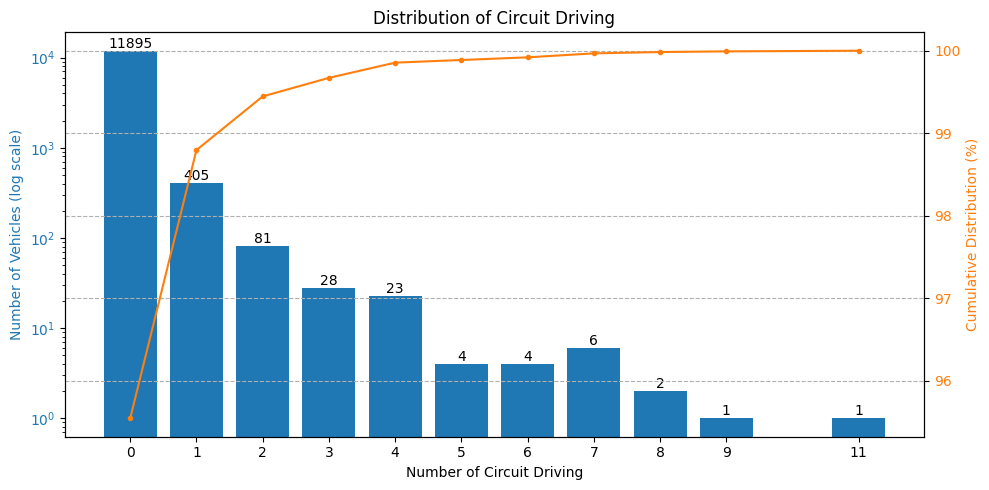

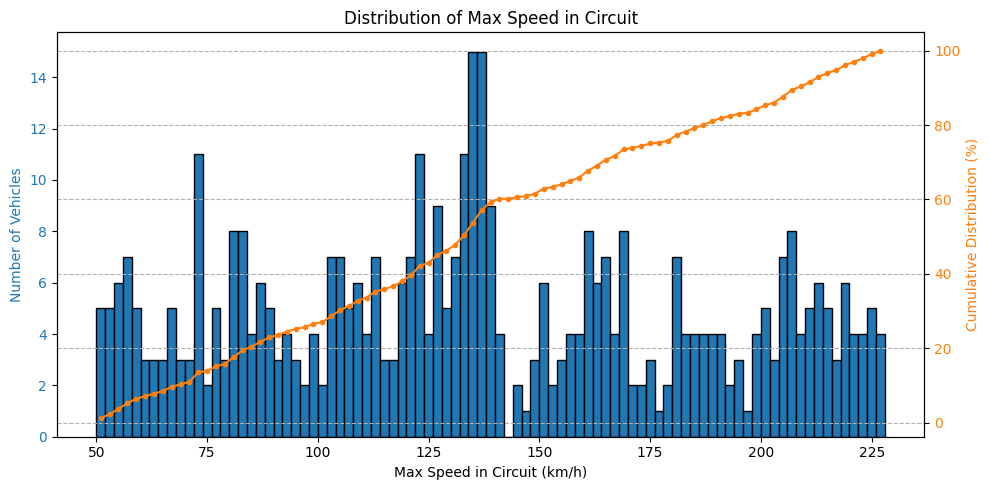

In [0]:
# 描画（走行回数）
plot_count_distribution_with_cdf(
    tables_pddf,
    count_col='CIRCUIT_DRIVING_COUNT',
    plt_params={
    'figsize': (10, 5),
    'bar_color': 'C0',
    'xlabel': 'Number of Circuit Driving',
    'bar_ylabel': 'Number of Vehicles (log scale)',
    'bar_yscale': 'log',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Circuit Driving',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    }
)


# 描画（最高速度）
plot_distribution_with_cdf(
    tables_pddf,
    target_col='CIRCUIT_DRIVING_MAX_SPEED',
    plt_params={
    'figsize': (10, 5),
    'bin_width': 2,
    'bar_color': 'C0',
    'xlabel': 'Max Speed in Circuit (km/h)',
    'bar_ylabel': 'Number of Vehicles',
    'bar_yscale': 'linear',
    'cdf_ylabel': 'Cumulative Distribution (%)',
    'title': 'Distribution of Max Speed in Circuit',
    'cdf_color': 'C1',
    'cdf_marker': '.',
    'xlim': (None, None)
    }
)

### サーキット走行有無による違い（最高車速・最長走行距離）

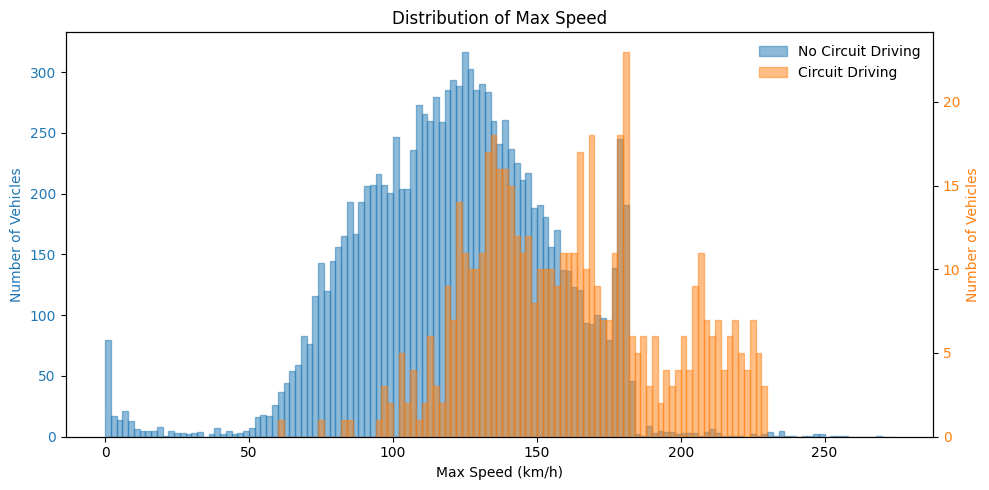

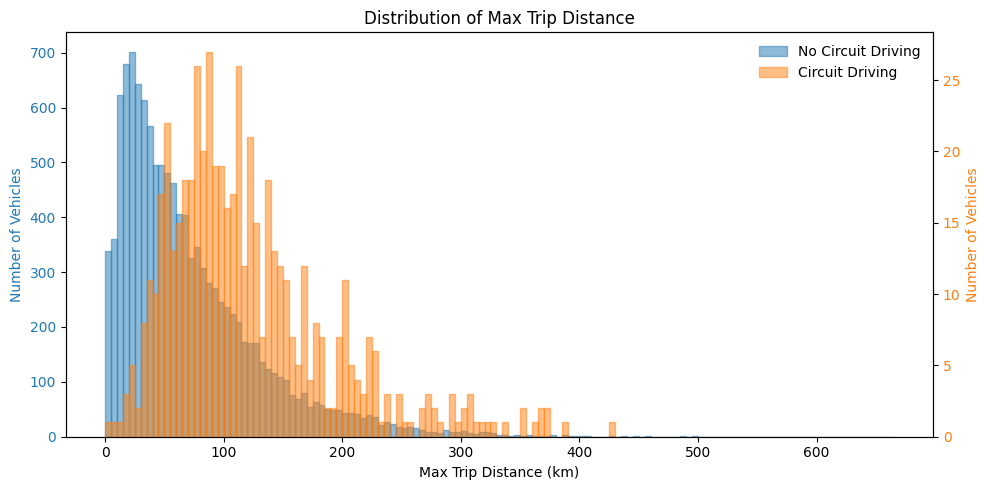

In [0]:
# 描画（最高車速）
plt_distribution_comparison(
    tables_pddf[(tables_pddf['CIRCUIT_DRIVING_COUNT'] == 0) | tables_pddf['CIRCUIT_DRIVING_COUNT'].isnull()],
    tables_pddf[tables_pddf['CIRCUIT_DRIVING_COUNT'] > 0],
    target_col='MAX_SPEED',
    plt_params={
        'figsize': (10, 5),
        'bin_width': 2,
        'color1': 'C0',
        'color2': 'C1',
        'label1': 'No Circuit Driving',
        'label2': 'Circuit Driving',
        'xlabel': 'Max Speed (km/h)',
        'ylabel1': 'Number of Vehicles',
        'ylabel2': 'Number of Vehicles',
        'title': 'Distribution of Max Speed',
        'alpha': 0.5,
        'legend_loc': 'upper right'
    }
)


# 描画（最長走行距離）
plt_distribution_comparison(
    tables_pddf[(tables_pddf['CIRCUIT_DRIVING_COUNT'] == 0) | tables_pddf['CIRCUIT_DRIVING_COUNT'].isnull()],
    tables_pddf[tables_pddf['CIRCUIT_DRIVING_COUNT'] > 0],
    target_col='MAX_DISTANCE',
    plt_params={
        'figsize': (10, 5),
        'bin_width': 5,
        'color1': 'C0',
        'color2': 'C1',
        'label1': 'No Circuit Driving',
        'label2': 'Circuit Driving',
        'xlabel': 'Max Trip Distance (km)',
        'ylabel1': 'Number of Vehicles',
        'ylabel2': 'Number of Vehicles',
        'title': 'Distribution of Max Trip Distance',
        'alpha': 0.5,
        'legend_loc': 'upper right'
    }
)

## ルールベースのセグメンテーション

In [0]:
# 結果を保存するディレクトリとファイル名
SAVE_DIR = 'notebook/data/02_driver_segmentation'
FILE_NAME = '952w_segmentation_result_tables_dict.pkl'


# ココに任意の分類ルールを構築
def gryaris_segment_rule(df):
    # 閾値
    CIRCUIT_DRIVING_THRESHOLD = 1     
    CIRCUIT_DRIVING_MAXSPEED_THRESHOLD = 150   
    MAX_TRIP_DISTANCE_THRESHOLD = 40
    MAX_TRIP_SPEED_THRESHOLD = 100
    # ベクトル化
    highamateur = (df["CIRCUIT_DRIVING_COUNT"] >= CIRCUIT_DRIVING_THRESHOLD) & (df["CIRCUIT_DRIVING_MAX_SPEED"] >= CIRCUIT_DRIVING_MAXSPEED_THRESHOLD)
    middle      = (df["CIRCUIT_DRIVING_COUNT"] >= CIRCUIT_DRIVING_THRESHOLD) & (df["CIRCUIT_DRIVING_MAX_SPEED"] <  CIRCUIT_DRIVING_MAXSPEED_THRESHOLD)
    light       = (df["CIRCUIT_DRIVING_COUNT"] < CIRCUIT_DRIVING_THRESHOLD) & (df["MAX_DISTANCE"] >= MAX_TRIP_DISTANCE_THRESHOLD) | (df["MAX_DISTANCE"] >= MAX_TRIP_SPEED_THRESHOLD)
    entry       = (df["CIRCUIT_DRIVING_COUNT"] < CIRCUIT_DRIVING_THRESHOLD) & (df["MAX_DISTANCE"] < MAX_TRIP_DISTANCE_THRESHOLD) | (df["MAX_DISTANCE"] < MAX_TRIP_SPEED_THRESHOLD)
    return [highamateur, middle, light, entry]


# データテーブルごと得セグメンテーションを実行
segmentation_result_tables_dict = {}
for key, table_pddf in tables_for_segmentation_dict.items():
    print(f'[{key}]')
    segmentation_result_tables_dict[key] = rule_based_segmentation(
        table_pddf, 
        gryaris_segment_rule,
        segment_names=["High-Amateur", "Middle", "Light", "Entry"],
        default_segment_name="Entry",
        segment_column_name="SEGMENT",
        )


# 結果を保存
save_pkl(SAVE_DIR, FILE_NAME, segmentation_result_tables_dict)

[202410]
Segmentation result (Total Sample:  1526
Light           1016
Entry            413
Middle            57
High-Amateur      40
Name: SEGMENT, dtype: int64
[202504]
Segmentation result (Total Sample:  4151
Light           2532
Entry           1436
Middle           112
High-Amateur      71
Name: SEGMENT, dtype: int64
[202510]
Segmentation result (Total Sample:  6773
Light           3819
Entry           2679
Middle           182
High-Amateur      93
Name: SEGMENT, dtype: int64


## 結果を可視化

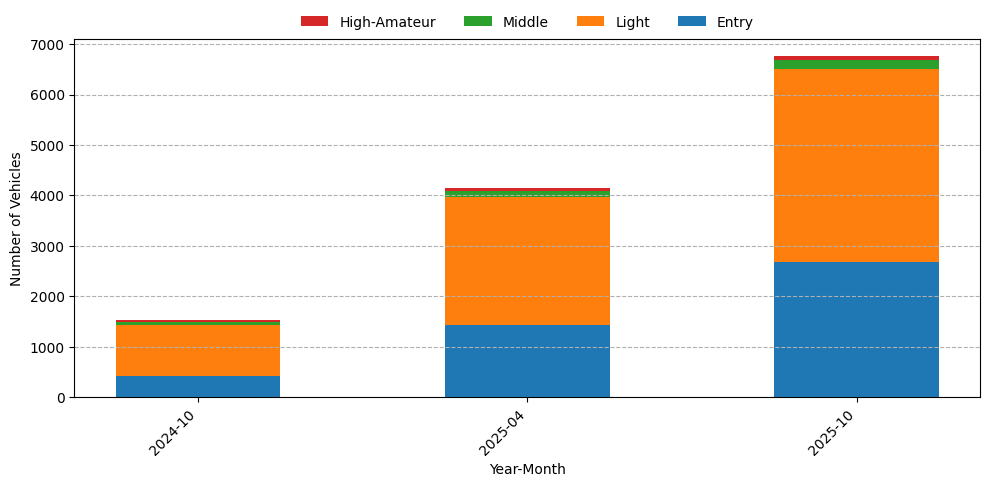

,N,High-Amateur,Middle,Light,Entry
YYYYMM,,,,,
202410,1526,40,57,1016,413
202504,4151,71,112,2532,1436
202510,6773,93,182,3819,2679


In [0]:
# セグメント結果を集計
N_pdser, counts_pddf, pct_pddf = count_segmentation_result(segmentation_result_tables_dict)

# 可視化
plot_segmentation_result(
    segmentation_result_tables_dict,
    y_100pct=False,
    figsize=(10, 5),
)

# 集計テーブル
result_pddf = pd.concat([N_pdser, counts_pddf], axis=1)
result_pddf.index.name = 'YYYYMM'
result_pddf

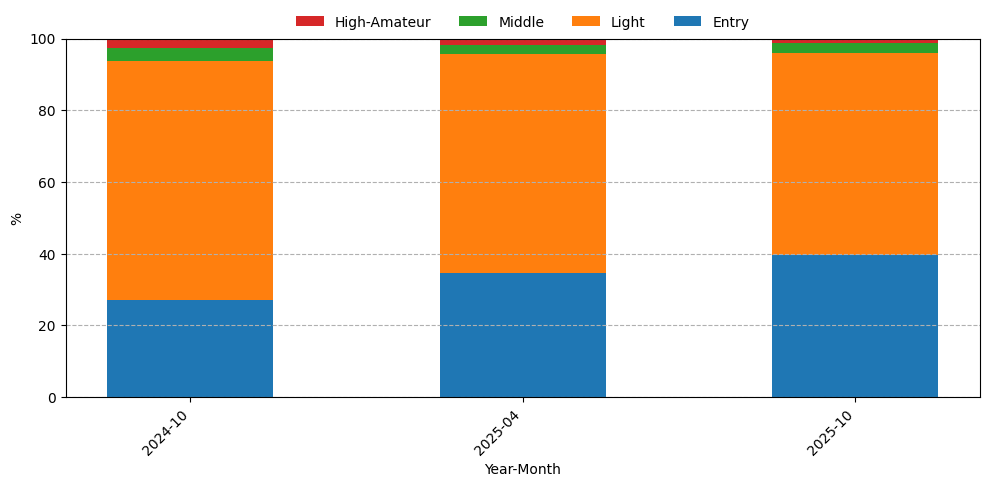

,N,High-Amateur(%),Middle(%),Light(%),Entry(%)
YYYYMM,,,,,
202410,1526,2.6,3.7,66.6,27.1
202504,4151,1.7,2.7,61.0,34.6
202510,6773,1.4,2.7,56.4,39.6


In [0]:
# 可視化(構成比)
plot_segmentation_result(
    segmentation_result_tables_dict,
    y_100pct=True,
    figsize=(10, 5),
)

# 集計テーブル(構成比)
result_pddf = pd.concat([N_pdser, pct_pddf], axis=1)
result_pddf.index.name = 'YYYYMM'
result_pddf

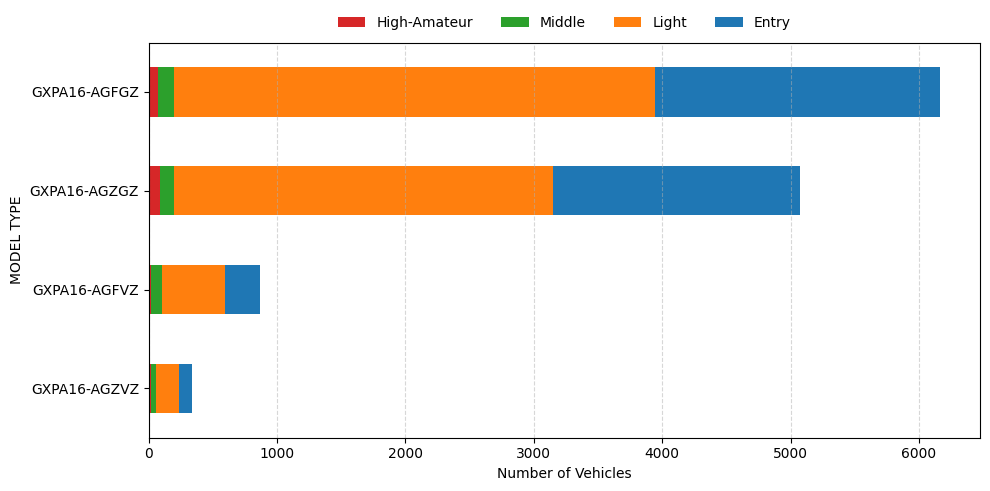

,N,High-Amateur,Middle,Light,Entry
MODEL TYPE,,,,,
GXPA16-AGFGZ,6167,73,123,3746,2225
GXPA16-AGZGZ,5074,88,111,2953,1922
GXPA16-AGFVZ,869,22,83,490,274
GXPA16-AGZVZ,340,21,34,178,107


In [0]:
# セグメント結果を集計
N_pdser, counts_pddf, pct_pddf = count_segmentation_result_by_modeltype(segmentation_result_tables_dict)

# 可視化
plot_segments_by_modeltype(
    segmentation_result_tables_dict,
    x_100pct=False,
    figsize=(10, 5),
    legend_h=1.1,
    color=['C3', 'C2', 'C1', 'C0'],
)

# 集計テーブル
result_pddf = pd.concat([N_pdser, counts_pddf], axis=1)
result_pddf.index.name = 'MODEL TYPE'
result_pddf


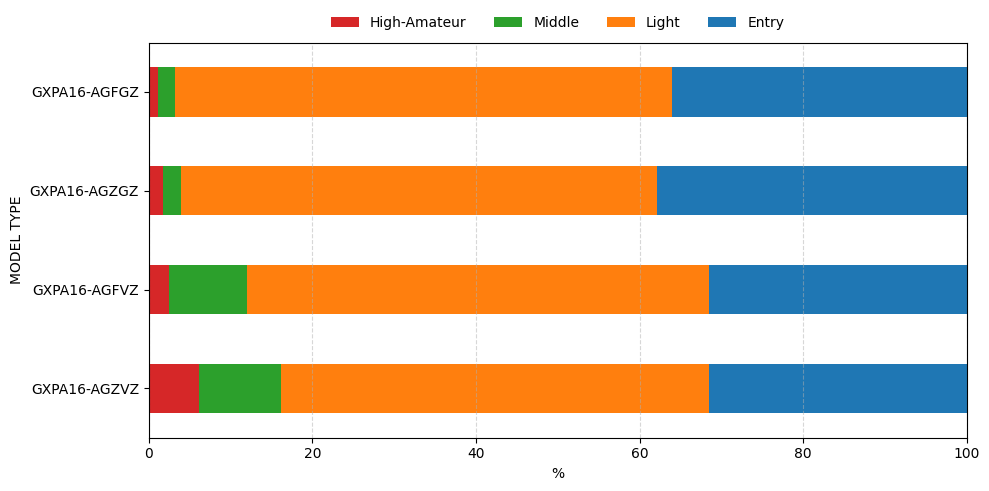

,N,High-Amateur(%),Middle(%),Light(%),Entry(%)
MODEL TYPE,,,,,
GXPA16-AGFGZ,6167,1.18,1.99,60.74,36.08
GXPA16-AGZGZ,5074,1.73,2.19,58.20,37.88
GXPA16-AGFVZ,869,2.53,9.55,56.39,31.53
GXPA16-AGZVZ,340,6.18,10.00,52.35,31.47


In [0]:
# 可視化(構成比)
plot_segments_by_modeltype(
    segmentation_result_tables_dict,
    x_100pct=True,
    figsize=(10, 5),
    legend_h=1.1,
    color=['C3', 'C2', 'C1', 'C0'],
)

# 集計テーブル(構成比)
result_pddf = pd.concat([N_pdser, pct_pddf], axis=1)
result_pddf.index.name = 'MODEL TYPE'
result_pddf